In [29]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import random_split

In [30]:
# 1. 사용할 디바이스 지정 (NVIDIA GPU -> Mac GPU -> CPU 순서)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():  # M1/M2/M3 맥북 유저용
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"현재 사용 중인 디바이스: {device}")

현재 사용 중인 디바이스: cuda


### 학습 데이터 설정


In [31]:
train_dataset = datasets.MNIST(
    root="data/mnist_data/", train=True, transform=transforms.ToTensor(), download=True
)
test_dataset = datasets.MNIST(
    root="data/mnist_data/", train=False, transform=transforms.ToTensor(), download=True
)

In [32]:
train_dataset_size = int(len(train_dataset) * 0.80)
validation_dataset_size = len(train_dataset) - train_dataset_size

train_dataset, validation_dataset = random_split(
    train_dataset, [train_dataset_size, validation_dataset_size]
)

print(len(train_dataset), len(validation_dataset), len(test_dataset))

48000 12000 10000


In [33]:
BATCH_SIZE = 64

train_dataset_loader = DataLoader(
    dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
validation_dataset_loader = DataLoader(
    dataset=validation_dataset, batch_size=BATCH_SIZE, shuffle=True
)
test_dataset_loader = DataLoader(
    dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

### 데이터 확인


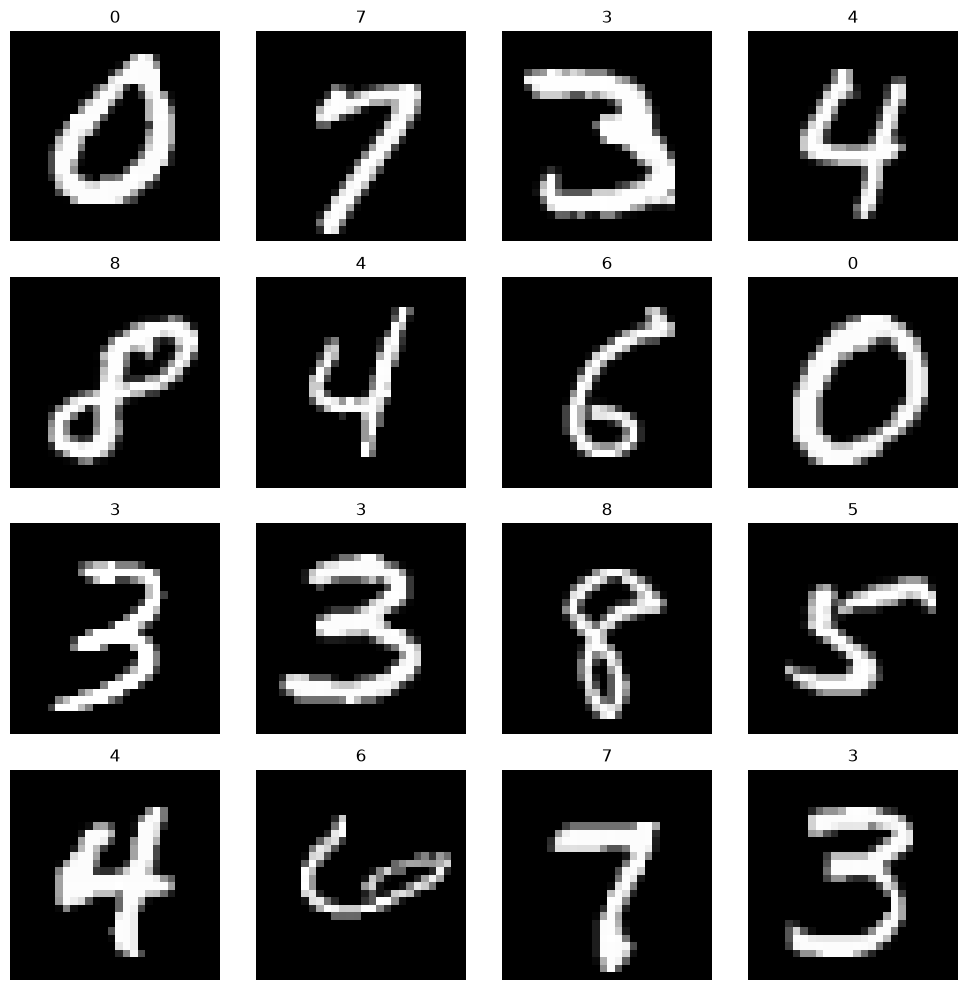

In [34]:
sample_data = next(iter(train_dataset_loader))

plt.figure(figsize=(10, 10))

for idx in range(16):
    images, labels = sample_data

    plt.subplot(4, 4, idx + 1)

    plt.imshow(images[idx].squeeze(), cmap="gray")
    plt.title(labels[idx].item())

    plt.axis("off")

plt.tight_layout()
plt.show()

### 모델 생성


In [35]:
class CnnModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.3),
        )
        self.linear_block = nn.Sequential(
            nn.Linear(7 * 7 * 64, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 10)
        )

    def forward(self, data):
        data = self.conv_block(data)
        data = data.view(-1, 7 * 7 * 64)
        logits = self.linear_block(data)
        return logits

In [36]:
model = CnnModel()

loss_function = (
    nn.CrossEntropyLoss()
)  # CrossEntropyLoss 손실함수에는 softmax 함수 포함되어 있음
optim = torch.optim.Adam(model.parameters(), lr=1e-3)

In [37]:
from torchinfo import summary

summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CnnModel                                 [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─ReLU: 2-2                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-3                    [1, 32, 14, 14]           --
│    └─Dropout: 2-4                      [1, 32, 14, 14]           --
│    └─Conv2d: 2-5                       [1, 64, 14, 14]           18,496
│    └─ReLU: 2-6                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-7                    [1, 64, 7, 7]             --
│    └─Dropout: 2-8                      [1, 64, 7, 7]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Linear: 2-9                       [1, 512]                  1,606,144
│    └─ReLU: 2-10                        [1, 512]                  --
│  

### 학습 및 검증 함수 선언


In [38]:
def model_train(
    dataloader: DataLoader,
    model: CnnModel,
    loss_function: nn.CrossEntropyLoss,
    optim: torch.optim.SGD,
):

    model.train()

    loss_sum = train_correct = total_count = 0
    batch_count = len(dataloader)

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_function(outputs, labels)

        optim.zero_grad()
        loss.backward()
        optim.step()

        loss_sum += loss.item()

        total_count += labels.size(0)
        train_correct += ((torch.argmax(outputs, 1) == labels)).sum().item()

    avg_loss = loss_sum / batch_count
    avg_accuracy = 100 * train_correct / total_count

    return (avg_loss, avg_accuracy)

In [39]:
def model_evaluate(
    dataloader: DataLoader,
    model: CnnModel,
    loss_function: nn.CrossEntropyLoss,
):

    model.eval()

    with torch.no_grad():

        loss_sum = correct_list = total_count = 0
        batch_count = len(dataloader)

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            loss_sum += loss.item()

            total_count += labels.size(0)
            correct_list += ((torch.argmax(outputs, 1) == labels)).sum().item()

        avg_loss = loss_sum / batch_count
        avg_accuracy = 100 * correct_list / total_count

    return (avg_loss, avg_accuracy)

In [40]:
def model_test(
    dataloader: DataLoader,
    model: CnnModel,
    loss_function: nn.CrossEntropyLoss,
):

    model.eval()

    with torch.no_grad():

        loss_sum = correct_list = total_count = 0
        batch_count = len(dataloader)

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            loss_sum += loss.item()

            total_count += labels.size(0)
            correct_list += ((torch.argmax(outputs, 1) == labels)).sum().item()

        avg_loss = loss_sum / batch_count
        avg_accuracy = 100 * correct_list / total_count

    print("accuracy:", avg_accuracy)
    print("loss:", avg_loss)

In [41]:
train_loss_list = []
train_accuracy_list = []

val_loss_list = []
val_accuracy_list = []

EPOCHS = 10

for epoch in range(EPOCHS):

    # ================== model train ======================
    train_avg_loss, train_avg_accuracy = model_train(
        train_dataset_loader, model, loss_function, optim
    )

    train_loss_list.append(train_avg_loss)
    train_accuracy_list.append(train_avg_accuracy)
    # =====================================================

    # ================== model evaluation =================
    val_avg_loss, val_avg_accuracy = model_evaluate(
        validation_dataset_loader, model, loss_function
    )

    val_loss_list.append(val_avg_loss)
    val_accuracy_list.append(val_avg_accuracy)
    # =====================================================

    print(
        f"epoch: {epoch}, train loss= {train_avg_loss}, train accuracy= {train_avg_accuracy},"
        f"validation loss= {val_avg_loss}, validation accuracy= {val_avg_accuracy}"
    )

epoch: 0, train loss= 0.22435588427757222, train accuracy= 92.85,validation loss= 0.06514957313861777, validation accuracy= 98.03333333333333
epoch: 1, train loss= 0.0740006040694813, train accuracy= 97.73333333333333,validation loss= 0.04184555779260762, validation accuracy= 98.73333333333333
epoch: 2, train loss= 0.05648459096159786, train accuracy= 98.29375,validation loss= 0.03634087634619643, validation accuracy= 98.875
epoch: 3, train loss= 0.04699590168939903, train accuracy= 98.5125,validation loss= 0.04056495358112288, validation accuracy= 98.68333333333334
epoch: 4, train loss= 0.039155408104804036, train accuracy= 98.73333333333333,validation loss= 0.03149649274595542, validation accuracy= 99.025
epoch: 5, train loss= 0.034476913986106715, train accuracy= 98.88541666666667,validation loss= 0.037671233257377874, validation accuracy= 98.91666666666667
epoch: 6, train loss= 0.030159506571750778, train accuracy= 98.99583333333334,validation loss= 0.03201704645533105, validation 

### 모델 테스트


In [42]:
model_test(test_dataset_loader, model, loss_function)

accuracy: 99.28
loss: 0.02226803653382687
